In [1]:
import os
import numpy as np
import pandas as pd
import tifffile

from matplotlib import pyplot as plt
import seaborn as sns


WTpath = "WT_JE2"
lcml262path = "LCML262"
dnaapath = "LCML1"
pcpath = "PC"

def read_csv(path):
    df = pd.read_csv(os.path.join(path, "batch_merged_analysis.csv"))
    return df


In [2]:
df_wt = read_csv(WTpath)
df_lcml262 = read_csv(lcml262path)
df_dnaa = read_csv(dnaapath)
df_pc = read_csv(pcpath)
df_wt.head()

,fov_name,fov_path,frame,label,Area,Perimeter,Eccentricity,Baseline,Cell Median,Membrane Median,Septum Median,Cytoplasm Median,Fluor Ratio,Fluor Ratio 75%,Fluor Ratio 25%,Fluor Ratio 10%,Cell Cycle Phase,DNA Ratio
0,10,/Users/adbrito/Documents/maicrobedatanadpaper/...,0,1,424.0,90.526912,0.899488,792.0,6875.5,10955.0,0,4955.0,0,0,0,0,3,0.771226
1,10,/Users/adbrito/Documents/maicrobedatanadpaper/...,0,2,38.0,26.414214,0.977820,1337.0,12029.0,12029.0,0,-1337.0,0,0,0,0,3,0.473684
2,10,/Users/adbrito/Documents/maicrobedatanadpaper/...,0,3,1221.0,128.811183,0.494114,1178.0,13026.0,19523.5,0,10728.0,0,0,0,0,1,0.882064
3,10,/Users/adbrito/Documents/maicrobedatanadpaper/...,0,4,1279.0,132.225397,0.566852,671.0,11236.0,13514.5,0,8777.0,0,0,0,0,3,0.917123
4,10,/Users/adbrito/Documents/maicrobedatanadpaper/...,0,5,765.0,100.669048,0.362932,1189.0,6129.0,12952.0,0,4880.0,0,0,0,0,1,0.908497


In [3]:
# Number of cells in each dataset
print(f"Number of cells in WT dataset: {len(df_wt)}")
print(f"Number of cells in LCML262 dataset: {len(df_lcml262)}")
print(f"Number of cells in DNAA dataset: {len(df_dnaa)}")
print(f"Number of cells in PC dataset: {len(df_pc)}")

Number of cells in WT dataset: 12831
Number of cells in LCML262 dataset: 3429
Number of cells in DNAA dataset: 1647
Number of cells in PC dataset: 4705


# Area and eccentricity of WT and PC

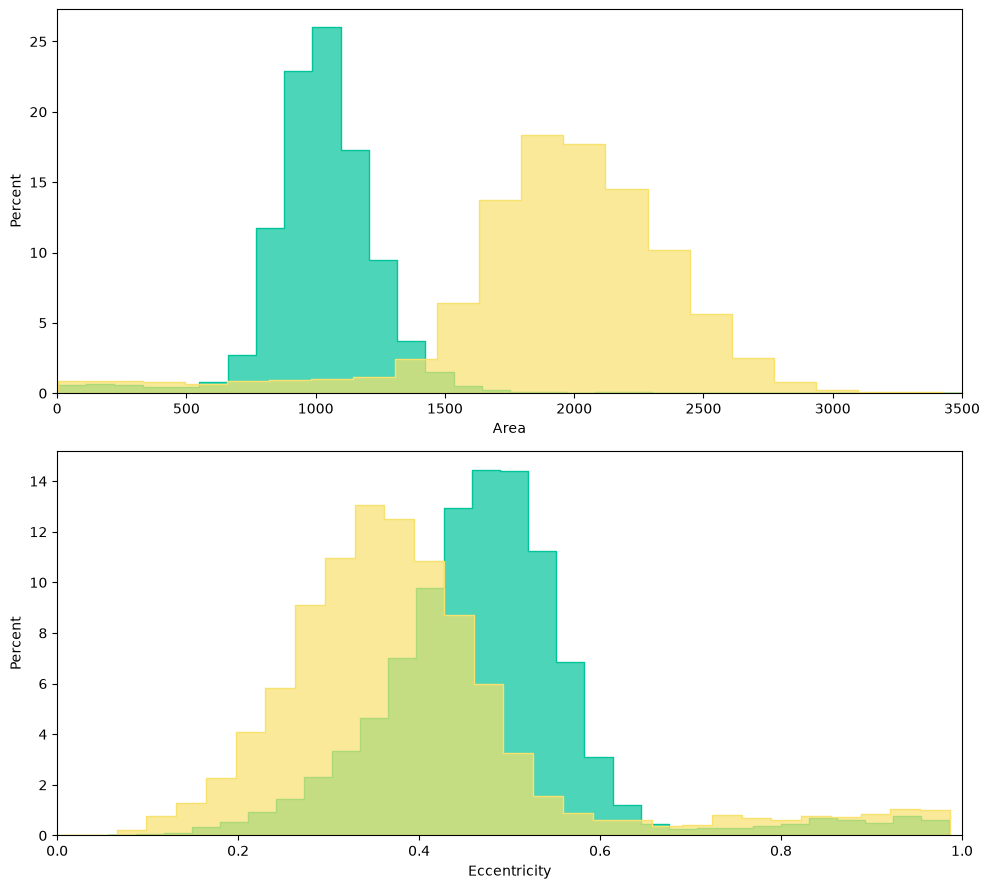

In [4]:
plt.figure(figsize=(10,9), dpi=100)

# Histogram for Area
plt.subplot(2, 1, 1)
sns.histplot(data = df_wt,x='Area', bins=50, alpha=0.7, label='Control', color="#00c49a", stat='percent', element='step')
sns.histplot(data = df_pc,x='Area', bins=30, alpha=0.7, label='PC', color="#f8e16c", stat='percent', element='step')
plt.xlim((0,3500))


# Histogram for Eccentricity
plt.subplot(2, 1, 2)
sns.histplot(data = df_wt,x='Eccentricity', bins=30, alpha=0.7, label='Control', color="#00c49a", stat='percent', element='step')
sns.histplot(data = df_pc,x='Eccentricity', bins=30, alpha=0.7, label='PC', color="#f8e16c", stat='percent', element='step')
plt.xlim((0,1))

plt.tight_layout()
plt.show()

# CCP of LCML1 and LCML262

Cell Cycle Phase
3    19.568387
1    50.306212
2    30.125401
Name: proportion, dtype: float64
Cell Cycle Phase
2    16.818458
1    61.870067
3    21.311475
Name: proportion, dtype: float64


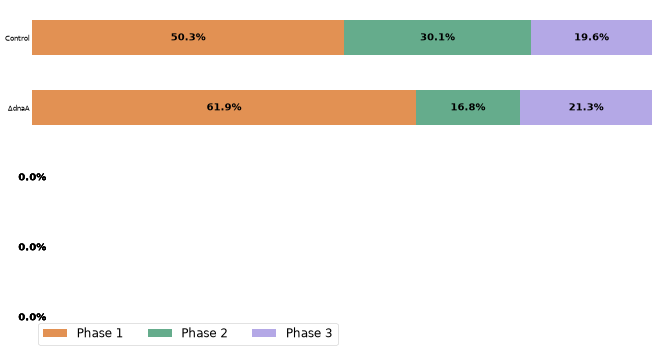

In [5]:
phase_counts_LCML262 = df_lcml262['Cell Cycle Phase'].value_counts(sort=False, normalize=True) * 100
print(phase_counts_LCML262)

phase_counts_LCML1 = df_dnaa['Cell Cycle Phase'].value_counts(sort=False, normalize=True) * 100
print(phase_counts_LCML1)

category_names = ['Phase 1', 'Phase 2', 'Phase 3']
results = {
    'Control': [phase_counts_LCML262[1], phase_counts_LCML262[2], phase_counts_LCML262[3]],
    '\u0394dnaA': [phase_counts_LCML1[1], phase_counts_LCML1[2], phase_counts_LCML1[3]],
    '': [0, 0, 0],  # Placeholder for empty categories
    '  ': [0, 0, 0],
    '   ': [0, 0, 0],
}


def survey(results, category_names):
    """
    Parameters
    ----------
    results : dict
        A mapping from question labels to a list of answers per category.
        It is assumed all lists contain the same number of entries and that
        it matches the length of *category_names*.
    category_names : list of str
        The category labels.
    """
    labels = list(results.keys())
    data = np.array(list(results.values()))
    data_cum = data.cumsum(axis=1)
    category_colors = ["#E29153","#65AC8C","#B4A8E6"]
    fig, ax = plt.subplots(figsize=(16, 9), dpi=50)
    ax.invert_yaxis()
    ax.xaxis.set_visible(False)
    ax.set_xlim(0, np.sum(data, axis=1).max())

    for i, (colname, color) in enumerate(zip(category_names, category_colors)):
        widths = data[:, i]
        starts = data_cum[:, i] - widths
        rects = ax.barh(labels, widths, left=starts, height=0.5,
                        label=colname, color=color)        
        text_color = 'black' 
        ax.bar_label(
            rects,
            labels=[f"{v:.1f}%" for v in widths],
            label_type='center',
            color=text_color,
            fontsize='x-large',
            fontweight='bold'
        )
        
    ax.legend(ncols=len(category_names),
              loc='lower left', fontsize='xx-large')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(axis='both', which='both', length=0)

    return fig, ax


survey(results, category_names)
plt.show()